In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

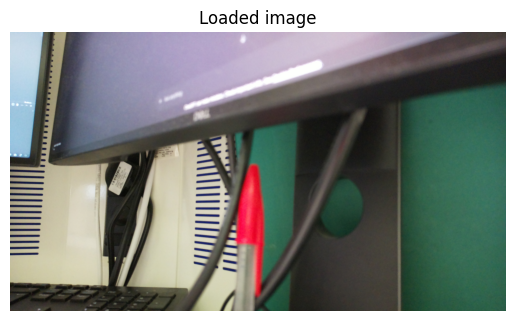

In [3]:
img = cv2.imread("../pictures/captured_frame.png")

if img is None:
    print("Image not found.")
else:
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(rgb)
    plt.axis("off")
    plt.title("Loaded image")
    plt.show()

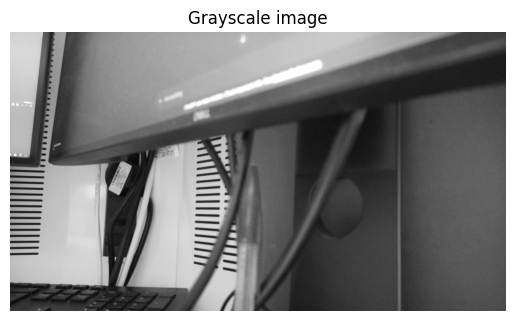

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale image")
plt.axis("off")
plt.show()

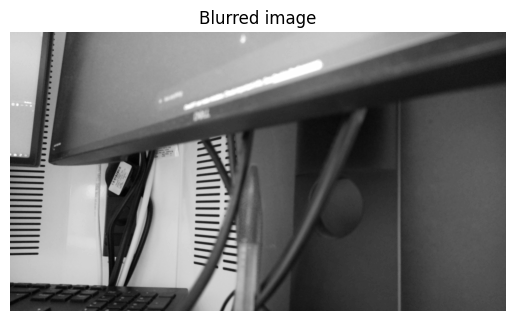

In [5]:
blur = cv2.GaussianBlur(gray, (9,9), 0)

plt.imshow(blur, cmap="gray")
plt.title("Blurred image")
plt.axis("off")
plt.show()

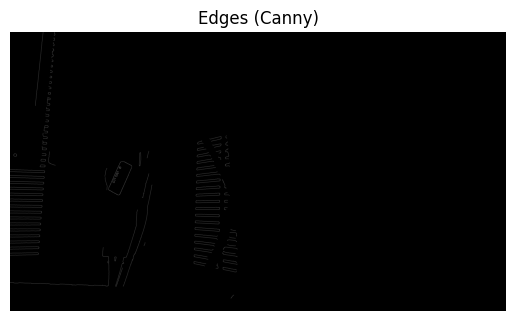

In [6]:
edges = cv2.Canny(blur, 50, 150)

plt.imshow(edges, cmap="gray")
plt.title("Edges (Canny)")
plt.axis("off")
plt.show()

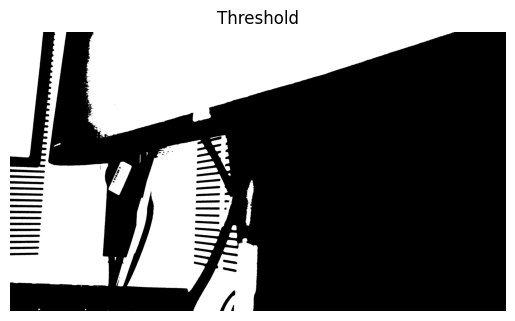

In [7]:
_, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

plt.imshow(thresh, cmap="gray")
plt.title("Threshold")
plt.axis("off")
plt.show()

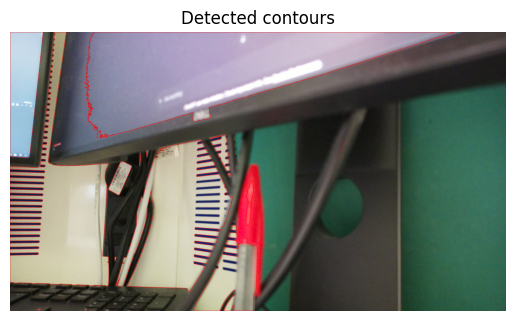

Contours found: 273


In [8]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

canvas = rgb.copy()
cv2.drawContours(canvas, contours, -1, (255,0,0), 2)

plt.imshow(canvas)
plt.title("Detected contours")
plt.axis("off")
plt.show()

print("Contours found:", len(contours))

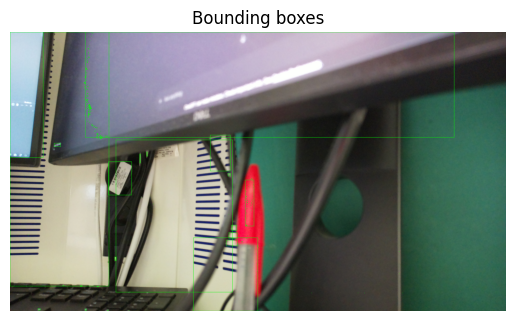

In [9]:
canvas = rgb.copy()

for c in contours:
    x,y,w,h = cv2.boundingRect(c)
    cv2.rectangle(canvas,(x,y),(x+w,y+h),(0,255,0),2)

plt.imshow(canvas)
plt.title("Bounding boxes")
plt.axis("off")
plt.show()